<a href="https://colab.research.google.com/github/joluva/datascience/blob/main/MOD3_Prueba_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importamos los paquetes que vamos a usar y definimos la ruta de trabajo**

In [ ]:
# importamos los paquetes para graficos, matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# importamos algunos paquetes auxiliares: datetime para trabajar con fechas y os para las rutas
import datetime
import os

# importamos las librerias pandas y numpy
import pandas as pd
import numpy as np

# usamos esta opcion para que muestre los datos en celda de output
%matplotlib inline

In [ ]:
# importamos el archivo con los datos y definimos un campo fecha
temp = pd.read_csv('datos_meteorologicos.csv', parse_dates=['fecha'])

# generamos una variable de amplitud térmica
temp['amplitud'] = temp['maxima'] - temp['minima']

# generamos un dateframe que contenga solo los datos de Aeroparque, primero hacemos una copia del original
aep=temp.copy()
aep=aep[aep['estacion'] == 'AEROPARQUE AERO']


# generamos una variable que contiene el año y el mes, para poder agregar
aep['mes'] = pd.to_datetime(aep['fecha']).dt.to_period('M')

<Axes: xlabel='fecha'>

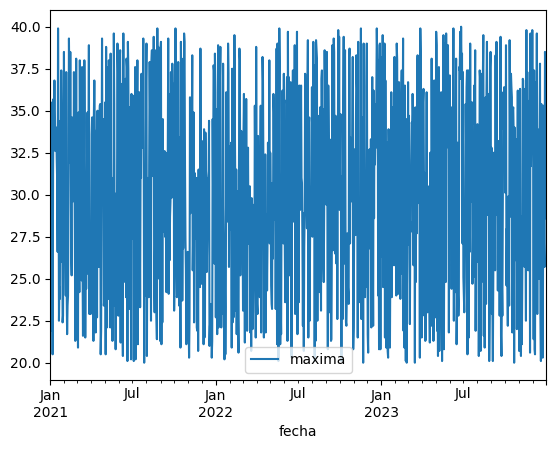

In [ ]:
# hacemos un un grafico de linea
aep.plot(x='fecha', y='maxima', kind='line')

**GRAFICO DE BARRAS, HISTOGRAMAS DE AREA**

In [ ]:
# agregamos las observaciones ( a nivel dia ) a los totales mensuales
aep_mes = aep.groupby(['mes'], as_index=False).agg({"maxima":"mean","minima":"mean"})
aep_mes

,mes,maxima,minima
0,2021-01,30.445161,8.329032
1,2021-02,29.896429,9.732143
2,2021-03,29.196774,10.303226
3,2021-04,29.943333,11.020000
4,2021-05,29.796774,7.416129
5,2021-06,30.816667,8.826667
6,2021-07,30.303226,11.322581
7,2021-08,30.935484,8.967742
8,2021-09,31.663333,8.730000
9,2021-10,29.125806,11.616129


<Axes: ylabel='mes'>

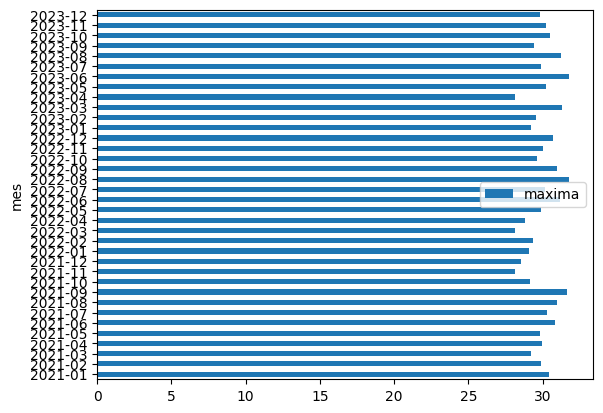

In [ ]:
# grafico de barras horizontales para la temperatura maxima por mes
aep_mes.plot(x='mes', y='maxima', kind='barh')

<Axes: title={'center': 'Amplitud termica'}, xlabel='mes', ylabel='Temperatura (°C)'>

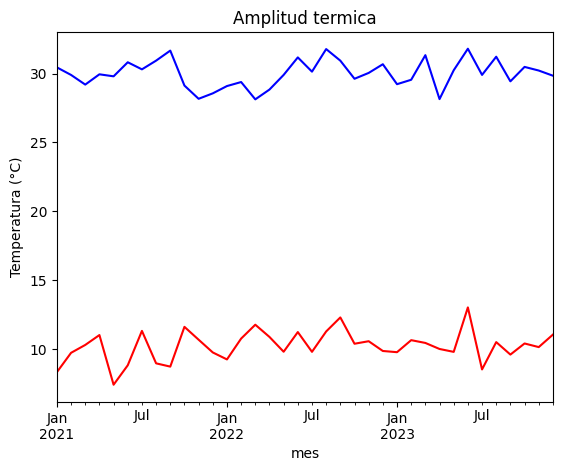

In [ ]:
# grafico de area apilada
aep_mes.plot(x='mes', y=['minima','maxima'], color=['red','blue'], title='Amplitud termica', ylabel='Temperatura (°C)',legend=False)

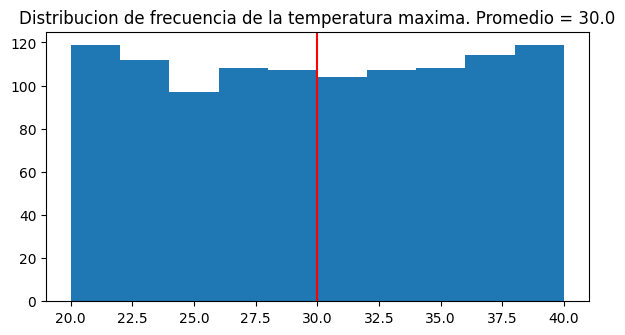

In [ ]:
# histograma para la temperatura maxima en aeroparque
plt.figure(figsize=(7,3.5))
plt.hist(aep['maxima'])
plt.title('Distribucion de frecuencia de la temperatura maxima. Promedio = ' + str(round(aep['maxima'].mean(),1)))
plt.axvline(x = aep['maxima'].mean(), color='red')


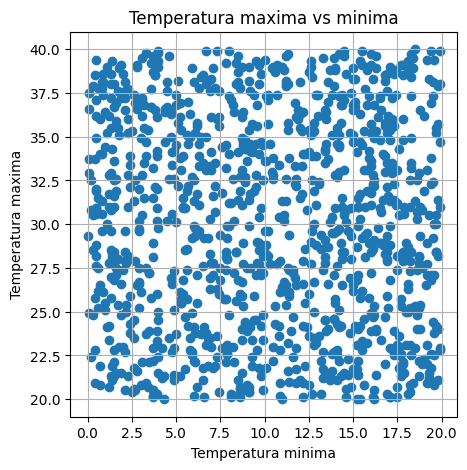

In [ ]:
# podemos cambiar el tamaño del grafico
plt.figure(figsize=(5,5))

# definimos el tipo de grafico (scatter) y las variables
plt.scatter(aep['minima'], aep['maxima'])

# definimos las etiquetas de los ejes
plt.xlabel('Temperatura minima')
plt.ylabel('Temperatura maxima')

# definimos el titulo del grafigo
plt.title('Temperatura maxima vs minima')

# incluimos las lineas de la grilla
plt.grid(True)

In [ ]:
np.corrcoef(aep['minima'], aep['maxima'])

array([[ 1.        , -0.03644846],
       [-0.03644846,  1.        ]])

Q1 =  24.8
Q2 o mediana =  30.1
Q3 =  35.15


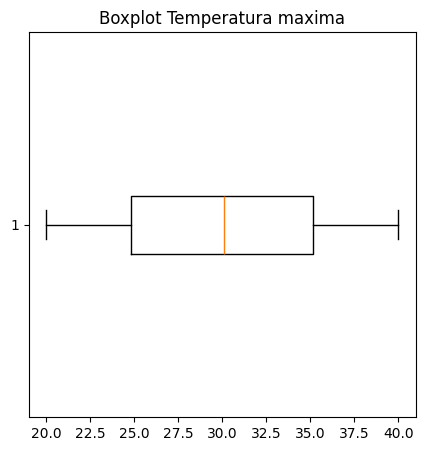

In [ ]:
# boxplot
plt.figure(figsize=(5,5))
plt.boxplot(aep['maxima'], vert=False)
plt.title('Boxplot Temperatura maxima')

print('Q1 = ', str(round(np.percentile(aep['maxima'],25), 2)))
print('Q2 o mediana = ', str(round(np.percentile(aep['maxima'],50), 2)))
print('Q3 = ', str(round(np.percentile(aep['maxima'],75), 2)))

**A partir de acá comenzamos a usar seaborn**

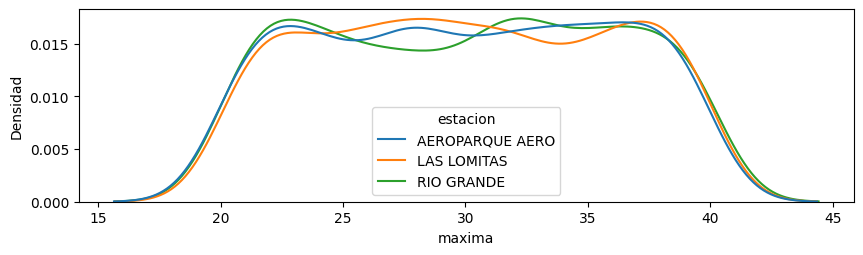

In [ ]:
# graficos de densidad
plt.figure(figsize=(10,2.5))
sns.kdeplot(data = temp, x='maxima', hue='estacion')
plt.ylabel('Densidad')
plt.show()